In [19]:
from glob import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.xarray
import holoviews as hv
import os
from cstes import  zarr_dir

In [ ]:
os.path.join(zarr_dir, "before_coloc", "wind", "era5_agesc_rio_z0.nc")

In [47]:
# To update old one
era15 = xr.open_dataset(
    "/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/wind/era5_agesc_rio_z15.nc"
)
era0 = xr.open_dataset(
    "/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/wind/era5_agesc_rio_z0.nc"
)
era0

<xarray.Dataset> Size: 4GB
Dimensions:           (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude         (longitude) float32 244B 0.0 0.25 0.5 ... 14.5 14.75 15.0
  * latitude          (latitude) float32 132B 44.0 43.75 43.5 ... 36.25 36.0
  * time              (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23...
Data variables: (12/62)
    u10               (time, latitude, longitude) float64 59MB ...
    v10               (time, latitude, longitude) float64 59MB ...
    t2m               (time, latitude, longitude) float64 59MB ...
    ewss              (time, latitude, longitude) float64 59MB ...
    iews              (time, latitude, longitude) float64 59MB ...
    inss              (time, latitude, longitude) float64 59MB ...
    ...                ...
    Us_agesc_z0       (latitude, time, longitude) float64 59MB ...
    Ues_agesc_z0      (time, latitude, longitude) float64 59MB ...
    Ue_rio_z0         (latitude, time, longitude) float64 59MB ...
    Ue_rioold_z0      (latitude, time, longitude) float64 59MB ...
    Ua_agesc_z0       (time, latitude, longitude) float64 59MB ...
    Uw_agesc_z0       (time, latitude, longitude) float64 59MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [48]:
era0

<xarray.Dataset> Size: 4GB
Dimensions:           (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude         (longitude) float32 244B 0.0 0.25 0.5 ... 14.5 14.75 15.0
  * latitude          (latitude) float32 132B 44.0 43.75 43.5 ... 36.25 36.0
  * time              (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23...
Data variables: (12/62)
    u10               (time, latitude, longitude) float64 59MB ...
    v10               (time, latitude, longitude) float64 59MB ...
    t2m               (time, latitude, longitude) float64 59MB ...
    ewss              (time, latitude, longitude) float64 59MB ...
    iews              (time, latitude, longitude) float64 59MB ...
    inss              (time, latitude, longitude) float64 59MB ...
    ...                ...
    Us_agesc_z0       (latitude, time, longitude) float64 59MB ...
    Ues_agesc_z0      (time, latitude, longitude) float64 59MB ...
    Ue_rio_z0         (latitude, time, longitude) float64 59MB ...
    Ue_rioold_z0      (latitude, time, longitude) float64 59MB ...
    Ua_agesc_z0       (time, latitude, longitude) float64 59MB ...
    Uw_agesc_z0       (time, latitude, longitude) float64 59MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [63]:
era0

<xarray.Dataset> Size: 4GB
Dimensions:           (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude         (longitude) float32 244B 0.0 0.25 0.5 ... 14.5 14.75 15.0
  * latitude          (latitude) float32 132B 44.0 43.75 43.5 ... 36.25 36.0
  * time              (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23...
Data variables: (12/62)
    u10               (time, latitude, longitude) float64 59MB ...
    v10               (time, latitude, longitude) float64 59MB ...
    t2m               (time, latitude, longitude) float64 59MB ...
    ewss              (time, latitude, longitude) float64 59MB ...
    iews              (time, latitude, longitude) float64 59MB ...
    inss              (time, latitude, longitude) float64 59MB ...
    ...                ...
    Us_agesc_z0       (latitude, time, longitude) float64 59MB ...
    Ues_agesc_z0      (time, latitude, longitude) float64 59MB ...
    Ue_rio_z0         (latitude, time, longitude) float64 59MB ...
    Ue_rioold_z0      (latitude, time, longitude) float64 59MB ...
    Ua_agesc_z0       (time, latitude, longitude) float64 59MB ...
    Uw_agesc_z0       (time, latitude, longitude) float64 59MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [74]:
era0_ = era0[['ue_rio_z0', 've_rio_z0']]
era0_ = era0_.rename({v:v.replace('_z0', '') for v in era0_})
era15_ = era15[['ue_rio_z15', 've_rio_z15']]
era15_ = era15_.rename({v:v.replace('_z15', '') for v in era15_})
era0_['depth'] = [0]
era15_['depth'] = [15]

era =xr.concat([era0_, era15_], dim='depth')
era['depth'] =era.depth.assign_attrs({'long_name':'Depth', 'unit':'m'})
#era =xr.merge([era, era0[['iews', 'inss', 'u10', 'v10']]])

In [76]:
era = era.assign_attrs({
    'description': "Ekman currents computed from instantaneous wind stress of ERA5 product (labeled iews and inss, https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview, see history attribute) with the Ekman model of Rio et al. 2014 and optimized parameters (see Text S1. of https://archimer.ifremer.fr/doc/01024/113590/128114.pdf or GRL Demol et al. 2026)", 
    'corresponding_contact':'margotdemol.oceano@proton.me'
})
era

<xarray.Dataset> Size: 237MB
Dimensions:    (depth: 2, latitude: 33, time: 3672, longitude: 61)
Coordinates:
  * longitude  (longitude) float32 244B 0.0 0.25 0.5 0.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 44.0 43.75 43.5 43.25 ... 36.5 36.25 36.0
  * time       (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
  * depth      (depth) int64 16B 0 15
Data variables:
    ue_rio     (depth, latitude, time, longitude) float64 118MB 0.01223 ... -...
    ve_rio     (depth, latitude, time, longitude) float64 118MB -0.04522 ... ...
Attributes:
    Conventions:            CF-1.6
    history:                2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1:...
    description:            Ekman currents computed from instantaneous wind s...
    corresponding_contact:  margotdemol.oceano@proton.me

In [77]:
era.to_netcdf("/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/wind/ERA5_rio_ekman_current_extraction_for_aurelien.nc")

In [50]:
era0_.rename({v.replace('_z0', '') for v in era0_})

['ue_rio_z0', 've_rio_z0']

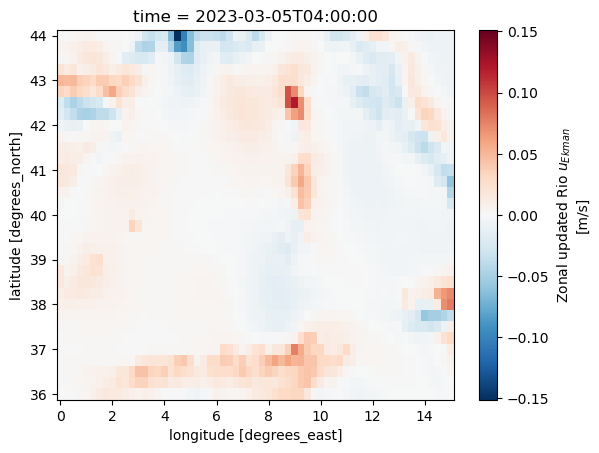

In [32]:
era.ue_rio_z15.isel(time=100).plot()

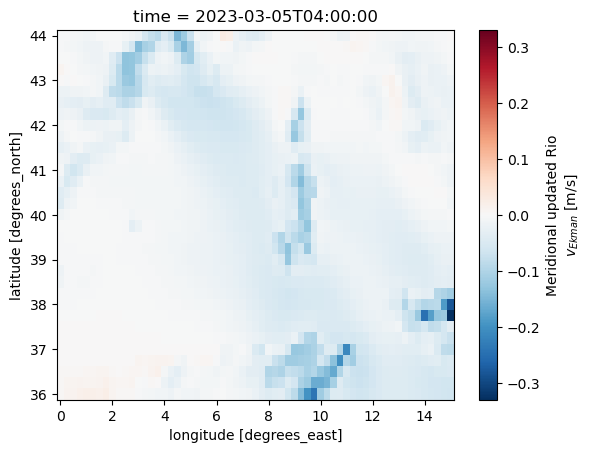

In [30]:
era.ve_rio_z15.isel(time=100).plot()